# Week 1 — Networks

Degrees, distributions and components in the Wikipedia link network of 303 Marvel
characters. This notebook produces every figure and every number in
[the week 1 post](../weeks/week1/week1.html).

Run it top to bottom. It writes SVGs into `weeks/week1/figures/`, overwriting
what is already there — so the published figures are always the output of the
code in this file, not something detached from it.

**Course:** 02805 Social Graphs and Interactions, DTU.
**Data:** the frozen week-1 snapshot, 26 August 2026.

In [1]:
import sys
sys.path.append("../src")

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

import marvel

marvel.use_site_style()

## 1. Loading the network

The one step worth being careful about. The edge list mentions only 286 of the
303 characters — 17 appear in neither column — so building the graph from edges
alone drops them silently. No exception, no warning, just a network that is
missing 6% of its nodes.

`marvel.load_graph()` adds the full node roster first. The assertion below is
the check that it worked.

In [2]:
G = marvel.load_graph()                 # directed
name = marvel.names(G)

n = G.number_of_nodes()
m_directed = G.number_of_edges()

print(f"nodes            {n}")
print(f"directed edges   {m_directed}")

assert n == 303, "node roster was not loaded before the edges"

nodes            303
directed edges   1784


### Checking against the course's published numbers

The course page states six quantities independently of us. Agreeing with all six
is the cheapest evidence available that the pipeline is right — it does not make
our *conclusions* right, but it rules out a broken load.

The two edge counts differ because some pairs link in both directions. Each of
those is two arrows but only one undirected pair.

In [3]:
U = G.to_undirected()
m_undirected = U.number_of_edges()
reciprocal = m_directed - m_undirected

avg_k = 2 * m_undirected / n
density = 2 * m_undirected / (n * (n - 1))

components = sorted(nx.connected_components(U), key=len, reverse=True)
isolates = [v for v in G.nodes() if G.degree(v) == 0]

checks = {
    "nodes":              (n,                    303),
    "directed edges":     (m_directed,           1784),
    "undirected pairs":   (m_undirected,         1434),
    "mean degree <k>":    (round(avg_k, 2),      9.47),
    "density":            (round(density, 3),    0.031),
    "giant component":    (len(components[0]),   277),
    "isolates":           (len(isolates),        17),
}

for label, (ours, published) in checks.items():
    flag = "OK " if ours == published else "MISMATCH"
    print(f"{flag} {label:<18} ours={ours:<8} course={published}")

print()
print(f"reciprocated pairs: {reciprocal}  "
      f"({m_directed} - {reciprocal} = {m_directed - reciprocal} undirected)")

OK  nodes              ours=303      course=303
OK  directed edges     ours=1784     course=1784
OK  undirected pairs   ours=1434     course=1434
OK  mean degree <k>    ours=9.47     course=9.47
OK  density            ours=0.031    course=0.031
OK  giant component    ours=277      course=277
OK  isolates           ours=17       course=17

reciprocated pairs: 350  (1784 - 350 = 1434 undirected)


## 2. Degree distributions

Four panels: in- and out-degree, each on linear and on log–log axes.

All four plot **k + 1** rather than k. A log axis cannot show zero, and 17
characters have no links at all — shifting keeps them in the picture instead of
quietly deleting them.

In [4]:
in_deg  = dict(G.in_degree())
out_deg = dict(G.out_degree())

print(f"in-degree   max {max(in_deg.values()):>3}   zeros {sum(v == 0 for v in in_deg.values())}")
print(f"out-degree  max {max(out_deg.values()):>3}   zeros {sum(v == 0 for v in out_deg.values())}")
print()
print("Both means must be identical — every arrow leaves one article and arrives")
print("at another, so both are m/n by construction. If they disagree, it is a bug.")
print(f"  mean in  = {np.mean(list(in_deg.values())):.4f}")
print(f"  mean out = {np.mean(list(out_deg.values())):.4f}")

in-degree   max 106   zeros 58
out-degree  max  28   zeros 20

Both means must be identical — every arrow leaves one article and arrives
at another, so both are m/n by construction. If they disagree, it is a bug.
  mean in  = 5.8878
  mean out = 5.8878


### Validating the binning before trusting it

The binned curve is where a silent error would live: divide by the wrong width
and the plot still looks like a plot. The test is that where the bins are width
1, binning must reproduce the raw values exactly — averaging one integer with
itself is not an average.

In [5]:
print("in-degree, width-1 bins:")
ok_in = marvel.check_binning(in_deg)

print("\nout-degree, width-1 bins:")
ok_out = marvel.check_binning(out_deg)

assert ok_in and ok_out, "binning normalisation is wrong"
print("\nbinning validated")

in-degree, width-1 bins:
  u=1   binned=0.191419  raw=0.191419  OK
  u=2   binned=0.135314  raw=0.135314  OK
  u=3   binned=0.141914  raw=0.141914  OK
  u=4   binned=0.092409  raw=0.092409  OK
  u=5   binned=0.069307  raw=0.069307  OK
  u=6   binned=0.072607  raw=0.072607  OK
  u=7   binned=0.042904  raw=0.042904  OK

out-degree, width-1 bins:
  u=1   binned=0.066007  raw=0.066007  OK
  u=2   binned=0.102310  raw=0.102310  OK
  u=3   binned=0.122112  raw=0.122112  OK
  u=4   binned=0.132013  raw=0.132013  OK
  u=5   binned=0.102310  raw=0.102310  OK
  u=6   binned=0.069307  raw=0.069307  OK
  u=7   binned=0.052805  raw=0.052805  OK

binning validated


wrote weeks/week1/figures/in_linear.svg


wrote weeks/week1/figures/in_loglog.svg
wrote weeks/week1/figures/out_linear.svg


wrote weeks/week1/figures/out_loglog.svg


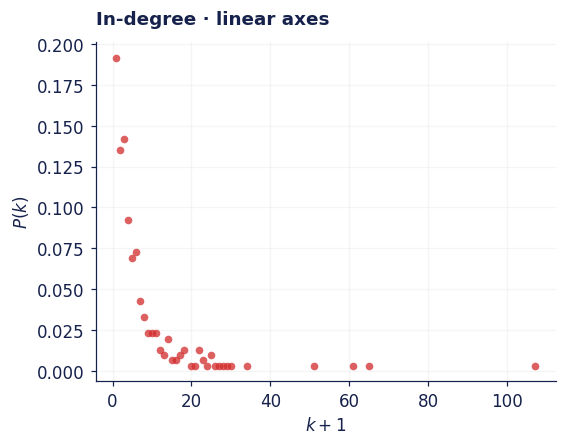

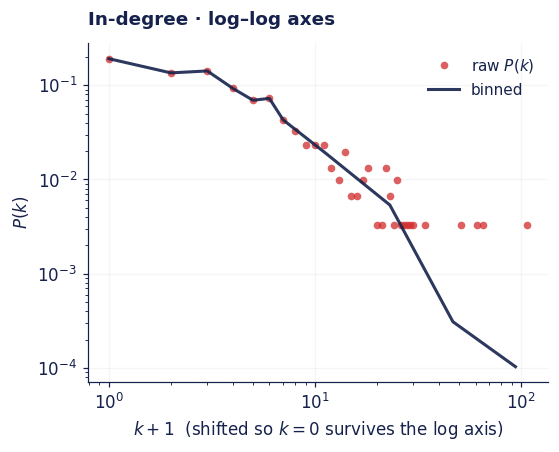

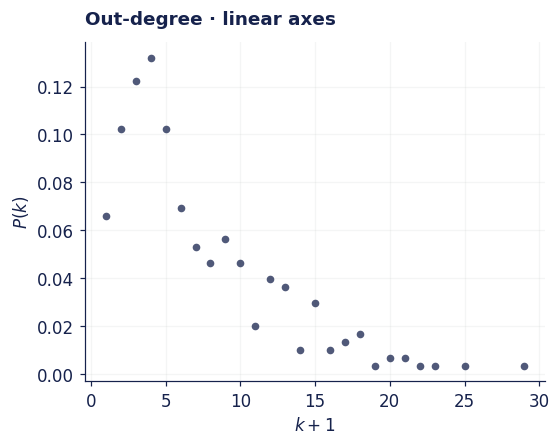

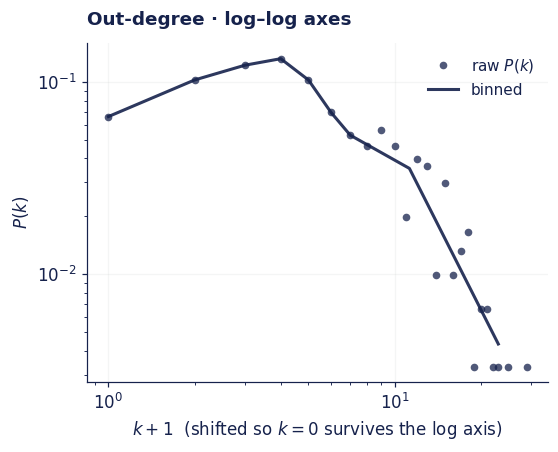

In [6]:
def degree_panel(degrees, kind, logaxes, filename, colour):
    ks, ps = marvel.distribution(degrees)

    fig, ax = plt.subplots(figsize=(5.4, 4.0))
    if logaxes:
        ax.loglog(ks + 1, ps, "o", ms=5, color=colour, alpha=.75,
                  mec="none", label="raw $P(k)$")
        bx, by = marvel.log_binned(degrees)
        ax.loglog(bx, by, "-", lw=2, color=marvel.INK, alpha=.9, label="binned")
        ax.set_xlabel("$k+1$  (shifted so $k=0$ survives the log axis)")
        ax.legend(frameon=False, fontsize=10)
    else:
        ax.plot(ks + 1, ps, "o", ms=5, color=colour, alpha=.75, mec="none")
        ax.set_xlabel("$k+1$")

    ax.set_ylabel("$P(k)$")
    ax.set_title(f"{kind}-degree · {'log–log' if logaxes else 'linear'} axes",
                 loc="left", fontsize=12, fontweight="bold", pad=12)
    ax.grid(alpha=.18, color=marvel.RULE)
    marvel.save(fig, 1, filename)
    return fig

degree_panel(in_deg,  "In",  False, "in_linear",  marvel.RED)
degree_panel(in_deg,  "In",  True,  "in_loglog",  marvel.RED)
degree_panel(out_deg, "Out", False, "out_linear", marvel.INK)
degree_panel(out_deg, "Out", True,  "out_loglog", marvel.INK)
plt.show()

## 3. Hubs — fame versus talkativeness

In-degree and out-degree pick out almost completely different characters, and
the mechanism is the reason: an in-link is *conferred* by somebody else's
article, an out-link has to be *authored* into this one.

In [7]:
def leaderboard(degrees, other, label, k=5):
    top = sorted(degrees, key=degrees.get, reverse=True)[:k]
    print(f"{label:<28}{'':>4}{'this':>6}{'other':>7}")
    for v in top:
        print(f"  {name[v][:26]:<28}{'':>2}{degrees[v]:>6}{other[v]:>7}")
    return top

leaderboard(in_deg, out_deg, "Most linked TO")
print()
leaderboard(out_deg, in_deg, "Links out MOST")

a = np.array([in_deg[v] for v in G])
b = np.array([out_deg[v] for v in G])
print(f"\ncorrelation between in and out degree: {np.corrcoef(a, b)[0, 1]:.3f}")
print("High enough that the two are related; far too low to use one as a proxy")
print("for the other.")

Most linked TO                    this  other
  Spider-Man                       106      9
  Hulk                              64     10
  Wolverine (character)             60     17
  Doctor Strange                    50     17
  Deadpool                          33     19

Links out MOST                    this  other
  Betsy Braddock                    28      7
  Cloak and Dagger (characte        24     11
  Adam Warlock                      22      8
  Venom (character)                 21     17
  She-Hulk                          20     29

correlation between in and out degree: 0.496
High enough that the two are related; far too low to use one as a proxy
for the other.


wrote weeks/week1/figures/in_vs_out.svg


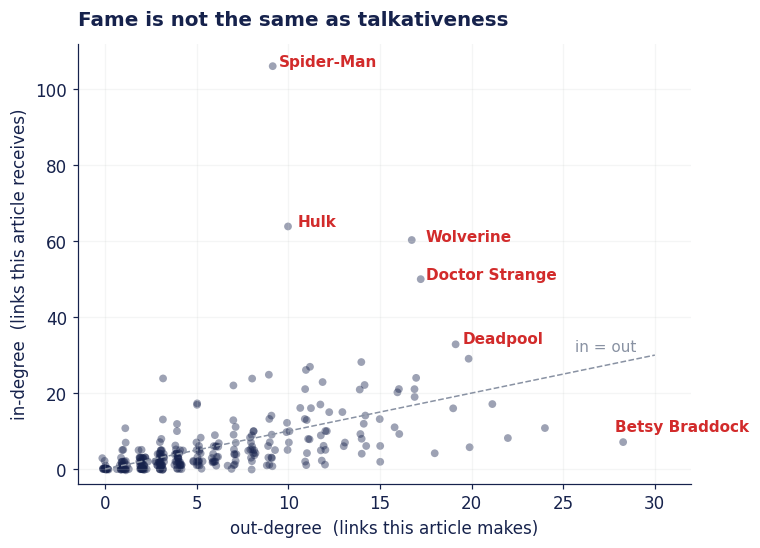

In [8]:
fig, ax = plt.subplots(figsize=(7.2, 5.2))
jit = np.random.default_rng(4)

xs = np.array([out_deg[v] for v in G])
ys = np.array([in_deg[v] for v in G])
ax.scatter(xs + jit.normal(0, .12, len(xs)),
           ys + jit.normal(0, .12, len(ys)),
           s=26, color=marvel.INK, alpha=.42, edgecolors="none")

ax.plot([0, 30], [0, 30], "--", lw=1, color=marvel.MUTED)
ax.text(29, 31, "in = out", color=marvel.MUTED, fontsize=10, ha="right")

for label, dx, dy in [("Spider-Man", 6, 0), ("Hulk", 6, 0),
                      ("Wolverine (character)", 6, 0), ("Doctor Strange", 6, 0),
                      ("Betsy Braddock", -2, 7), ("Deadpool", 6, 0)]:
    v = next(x for x in G if name[x] == label)
    ax.annotate(name[v].replace(" (character)", ""), (out_deg[v], in_deg[v]),
                textcoords="offset points", xytext=(dx, dy), fontsize=10,
                color=marvel.RED, fontweight="bold")

ax.set_xlabel("out-degree  (links this article makes)")
ax.set_ylabel("in-degree  (links this article receives)")
ax.set_ylim(-4, 112)
ax.set_xlim(-1.5, 32)
ax.set_title("Fame is not the same as talkativeness", loc="left",
             fontsize=13, fontweight="bold", pad=12)
ax.grid(alpha=.18, color=marvel.RULE)

marvel.save(fig, 1, "in_vs_out")
plt.show()

## 4. Components

19 components: one of 277, one of 9, and seventeen of one.

The nine is the find of the week. We did not know the series existed — we found
a disconnected clique and went to look up who they were.

In [9]:
giant, island = components[0], components[1]

print(f"components: {len(components)}   sizes: {[len(c) for c in components][:3]} ...")
print(f"\nthe island ({len(island)} characters):")
for v in sorted(island, key=lambda z: name[z]):
    print(f"   {name[v]}")

print(f"\nthe {len(isolates)} isolates:")
print("  " + ", ".join(sorted(name[v] for v in isolates)))

components: 19   sizes: [277, 9, 1] ...

the island (9 characters):
   Backhand (character)
   Blackthorn (character)
   Radian (Morituri)
   Scaredycat
   Scatterbrain (Morituri)
   Shear (character)
   Snapdragon (Morituri)
   Toxyn
   Vyking

the 17 isolates:
  Baymax, Bird-Brain (Marvel Comics), Black Fox (Robert Paine), Brain Drain (character), Breeze Barton, Captain Midlands, Charcoal (comics), Father Time (Marvel Comics), Happy Sam Sawyer, Hellfire (J. T. Slade), Illuminator (Marvel Comics), Miracleman (character), Ogre (Marvel Comics), Sean and Chris, Solarman, Super Rabbit, Yo-Yo Rodriguez


### Drawing all 303

The giant component gets a force-directed layout. The isolates and the island
do **not** — a force layout has nothing to say about a node with no edges, so it
would scatter them arbitrarily and invite the reader to find meaning in where
they landed. We place them deliberately instead, and say so in the caption.

wrote weeks/week1/figures/network.svg


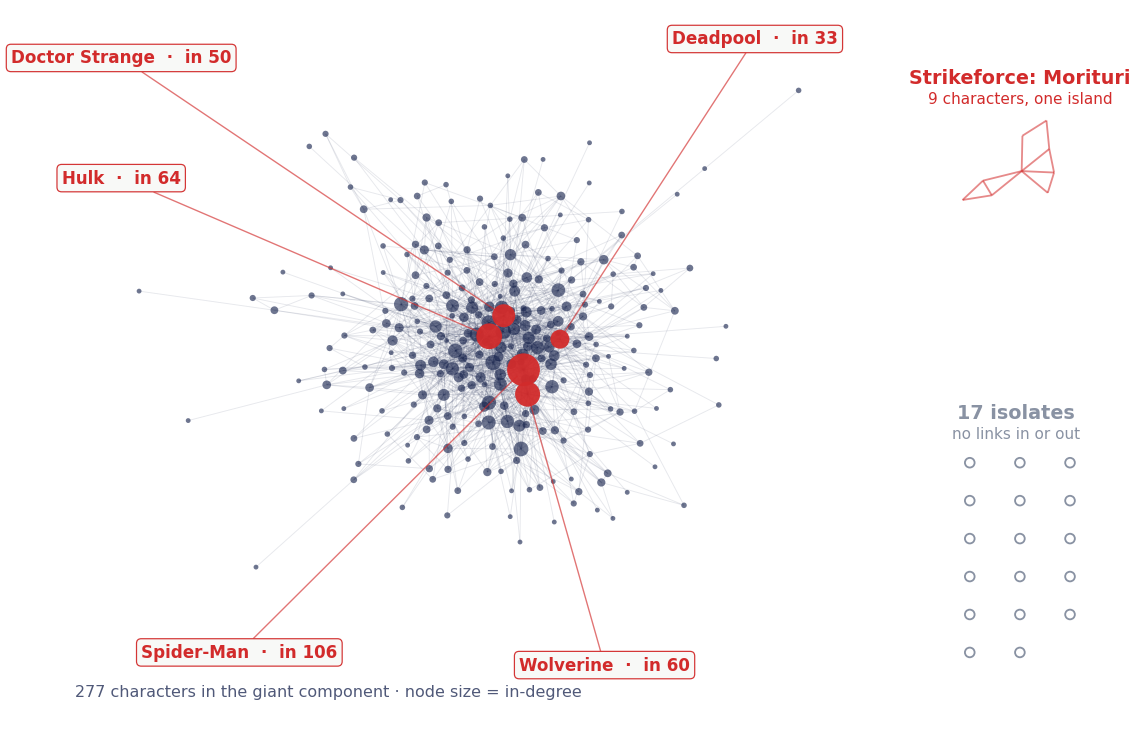

In [10]:
pos = nx.spring_layout(U.subgraph(giant), seed=17, k=.33, iterations=800)
P = np.array([pos[v] for v in giant])
P -= P.mean(0)
P /= np.abs(P).max()
pos = {v: P[i] for i, v in enumerate(giant)}

ip = nx.spring_layout(U.subgraph(island), seed=2, k=.6)
IP = np.array([ip[v] for v in island])
IP -= IP.mean(0)
IP /= np.abs(IP).max()
for i, v in enumerate(island):
    pos[v] = IP[i] * .16 + np.array([1.46, .55])

for i, v in enumerate(sorted(isolates, key=lambda z: name[z])):
    pos[v] = np.array([1.32 + (i % 3) * .14, -.38 - (i // 3) * .12])

hubs = sorted(giant, key=lambda v: in_deg[v], reverse=True)[:5]
rest = [v for v in giant if v not in hubs]

fig, ax = plt.subplots(figsize=(12.6, 8.4))
nx.draw_networkx_edges(U.subgraph(giant), pos, ax=ax,
                       edge_color=marvel.INK, alpha=.10, width=.6)
nx.draw_networkx_edges(U.subgraph(island), pos, ax=ax,
                       edge_color=marvel.RED, alpha=.55, width=1.2)
nx.draw_networkx_nodes(U.subgraph(giant), pos, nodelist=rest, ax=ax,
                       node_size=[10 + 3.2 * in_deg[v] for v in rest],
                       node_color=marvel.INK, alpha=.62, linewidths=0)
nx.draw_networkx_nodes(U.subgraph(giant), pos, nodelist=hubs, ax=ax,
                       node_size=[16 + 4.2 * in_deg[v] for v in hubs],
                       node_color=marvel.RED, alpha=.95, linewidths=0)
nx.draw_networkx_nodes(G.subgraph(isolates), pos, ax=ax, node_size=40,
                       node_color="none", edgecolors=marvel.MUTED, linewidths=1.2)

anchors = {"Spider-Man": (-.72, -.98), "Hulk": (-1.05, .52),
           "Wolverine (character)": (.30, -1.02),
           "Doctor Strange": (-1.05, .90), "Deadpool": (.72, .96)}
for label, xy in anchors.items():
    v = next(x for x in G if name[x] == label)
    short = name[v].replace(" (character)", "")
    ax.annotate(f"{short}  ·  in {in_deg[v]}", pos[v], xytext=xy, fontsize=11,
                fontweight="bold", color=marvel.RED, ha="center", va="center",
                arrowprops=dict(arrowstyle="-", color=marvel.RED, lw=.9,
                                alpha=.65, shrinkA=0, shrinkB=6),
                bbox=dict(boxstyle="round,pad=.28", fc=marvel.CARD,
                          ec=marvel.RED, lw=.8, alpha=.95))

ax.text(1.46, .82, "Strikeforce: Morituri", color=marvel.RED,
        fontsize=12.5, fontweight="bold", ha="center")
ax.text(1.46, .755, "9 characters, one island", color=marvel.RED,
        fontsize=10, ha="center")
ax.text(1.45, -.24, "17 isolates", color=marvel.MUTED,
        fontsize=12.5, fontweight="bold", ha="center")
ax.text(1.45, -.305, "no links in or out", color=marvel.MUTED,
        fontsize=10, ha="center")
ax.text(-1.18, -1.12,
        "277 characters in the giant component · node size = in-degree",
        color=marvel.INK, fontsize=10.5, ha="left", alpha=.75)

ax.set_xlim(-1.22, 1.78)
ax.set_ylim(-1.20, 1.05)
ax.axis("off")

marvel.save(fig, 1, "network")
plt.show()

wrote weeks/week1/figures/morituri.svg


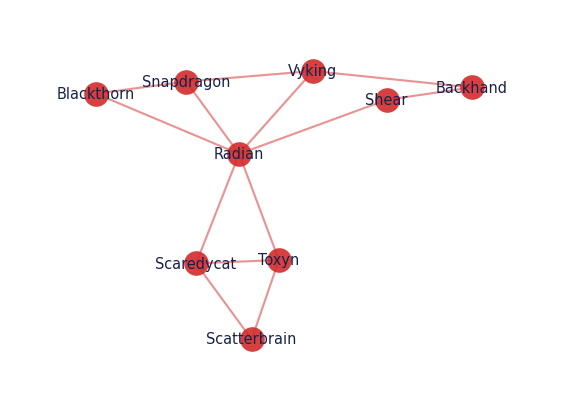

In [11]:
sub = U.subgraph(island)
p2 = nx.spring_layout(sub, seed=5, k=.85)

fig, ax = plt.subplots(figsize=(6.4, 4.6))
nx.draw_networkx_edges(sub, p2, ax=ax, edge_color=marvel.RED, alpha=.5, width=1.4)
nx.draw_networkx_nodes(sub, p2, ax=ax, node_size=260,
                       node_color=marvel.RED, alpha=.9, linewidths=0)
nx.draw_networkx_labels(
    sub, p2,
    {v: name[v].replace(" (character)", "").replace(" (Morituri)", "") for v in sub},
    font_size=9.5, ax=ax, font_color=marvel.INK)
ax.axis("off")
ax.margins(.16)

marvel.save(fig, 1, "morituri")
plt.show()

## 5. The asymmetry we did not expect

58 characters receive no links; only 20 make none. Writing an article nearly
forces you to link somewhere; being linked to requires somebody else to bother.

In [12]:
no_in  = [v for v in G if in_deg[v] == 0]
no_out = [v for v in G if out_deg[v] == 0]

print(f"in-degree  zero: {len(no_in):>3}")
print(f"out-degree zero: {len(no_out):>3}")
print(f"\nratio: {len(no_in) / len(no_out):.1f}x more unmentioned than silent")

in-degree  zero:  58
out-degree zero:  20

ratio: 2.9x more unmentioned than silent
